# Quantum ESPRESSO cube: z-averaged potential

This notebook reads a `*.cube` file written by Quantum ESPRESSO and plots the planar-averaged potential along the `z` direction.

Notes:
- The slab normal is assumed to be along the third cell direction.
- If the cube values are in Ry, set `convert_ry_to_ev = True`.
- If `cube_path = None`, a file picker window will open.


File: C:\Users\M-DESIGN\Desktop\1.50.cube
Grid shape: (108, 125, 360)
Cell lengths (Angstrom): [ 8.696117 10.041402 27.100308]
z range (Angstrom): 0.000000 -> 27.025029
Profile min/max: -0.697632 / 0.532745


,z_A,planar_average_raw
0,0.000000,-0.142106
1,0.075279,-0.232017
2,0.150557,-0.321139
3,0.225836,-0.407814
4,0.301115,-0.488373


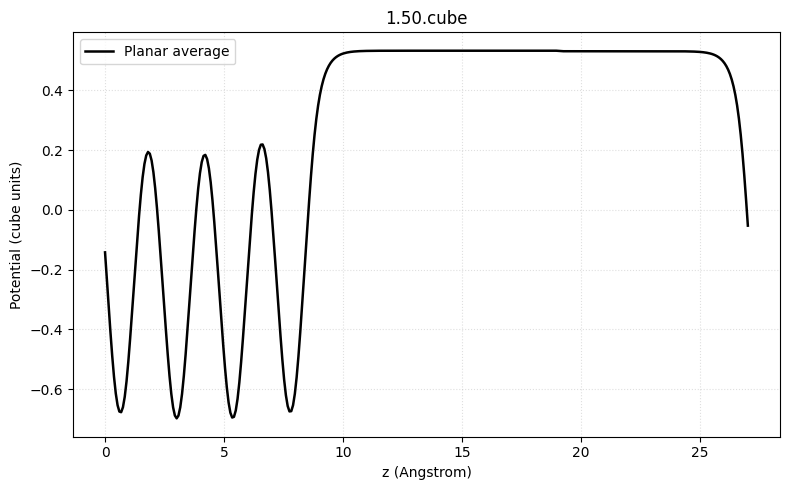

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ase.io import read
from tkinter import Tk, filedialog


RY_TO_EV = 13.605693009
cube_path = None
convert_ry_to_ev = False
smooth_window = 1
save_csv = False
output_csv = None

def choose_cube_file(initial_dir='.'):
    try:
        root = Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        file_path = filedialog.askopenfilename(
            title='Select a Quantum ESPRESSO cube file',
            initialdir=str(Path(initial_dir).resolve()),
            filetypes=[('Cube files', '*.cube'), ('All files', '*.*')],
        )
        root.destroy()
    except Exception as exc:
        raise RuntimeError(
            'File dialog could not be opened. Set cube_path manually in the next cell.'
        ) from exc

    if not file_path:
        raise FileNotFoundError('No cube file was selected.')

    return Path(file_path)


def load_cube_volume(cube_path):
    cube = read(str(cube_path), format='cube', read_data=True, full_output=True)
    data = np.asarray(cube['data'], dtype=float)
    atoms = cube['atoms']
    origin = np.asarray(cube.get('origin', np.zeros(3)), dtype=float)
    return data, atoms, origin


def planar_average(data, axis=2):
    if data.ndim != 3:
        raise ValueError(f'Expected a 3D cube array, got ndim={data.ndim}.')
    average_axes = tuple(i for i in range(data.ndim) if i != axis)
    return np.mean(data, axis=average_axes)


def axis_positions_from_cell(atoms, grid_shape, origin=None, axis=2):
    if axis not in (0, 1, 2):
        raise ValueError('axis must be 0, 1, or 2.')

    origin = np.zeros(3) if origin is None else np.asarray(origin, dtype=float)
    axis_vector = atoms.cell.array[axis] / grid_shape[axis]
    axis_points = origin + np.arange(grid_shape[axis])[:, None] * axis_vector
    axis_unit_vector = axis_vector / np.linalg.norm(axis_vector)
    return axis_points @ axis_unit_vector


def moving_average(values, window=1):
    values = np.asarray(values, dtype=float)
    window = int(window)

    if window <= 1:
        return values
    if window % 2 == 0:
        raise ValueError('smooth_window must be an odd integer.')
    if window > len(values):
        raise ValueError('smooth_window cannot be larger than the z-grid size.')

    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode='same')


def build_profile_dataframe(z_positions, profile_raw, profile_plot):
    df = pd.DataFrame(
        {
            'z_A': np.asarray(z_positions, dtype=float),
            'planar_average_raw': np.asarray(profile_raw, dtype=float),
        }
    )

    if not np.allclose(profile_raw, profile_plot):
        df['planar_average_smoothed'] = np.asarray(profile_plot, dtype=float)

    return df


def plot_z_average_potential(
    cube_path=None,
    convert_ry_to_ev=False,
    smooth_window=1,
    save_csv=False,
    output_csv=None,
):
    cube_path = choose_cube_file() if cube_path is None else Path(cube_path)
    cube_path = cube_path.expanduser().resolve()

    if not cube_path.exists():
        raise FileNotFoundError(f'Cube file not found: {cube_path}')

    data, atoms, origin = load_cube_volume(cube_path)

    z_positions = axis_positions_from_cell(atoms, data.shape, origin=origin, axis=2)
    profile_raw = planar_average(data, axis=2)

    y_label = 'Potential (cube units)'
    if convert_ry_to_ev:
        profile_raw = profile_raw * RY_TO_EV
        y_label = 'Potential (eV)'

    profile_plot = moving_average(profile_raw, window=smooth_window)
    profile_df = build_profile_dataframe(z_positions, profile_raw, profile_plot)

    fig, ax = plt.subplots(figsize=(8, 5))
    if smooth_window > 1:
        ax.plot(z_positions, profile_raw, color='0.75', linewidth=1.0, label='Planar average (raw)')
        ax.plot(
            z_positions,
            profile_plot,
            color='black',
            linewidth=1.8,
            label=f'Planar average (smoothed, window={smooth_window})',
        )
    else:
        ax.plot(z_positions, profile_plot, color='black', linewidth=1.8, label='Planar average')

    ax.set_xlabel('z (Angstrom)')
    ax.set_ylabel(y_label)
    ax.set_title(cube_path.name)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend()
    plt.tight_layout()

    print(f'File: {cube_path}')
    print(f'Grid shape: {data.shape}')
    print(f'Cell lengths (Angstrom): {np.round(atoms.cell.lengths(), 6)}')
    print(f'z range (Angstrom): {z_positions[0]:.6f} -> {z_positions[-1]:.6f}')
    print(f'Profile min/max: {profile_plot.min():.6f} / {profile_plot.max():.6f}')

    if save_csv:
        output_csv = cube_path.with_name(f'{cube_path.stem}_z_average.csv') if output_csv is None else Path(output_csv)
        output_csv = output_csv.expanduser().resolve()
        profile_df.to_csv(output_csv, index=False)
        print(f'Saved CSV: {output_csv}')

    return profile_df, fig, ax

profile_df, fig, ax = plot_z_average_potential(
    cube_path=cube_path,
    convert_ry_to_ev=convert_ry_to_ev,
    smooth_window=smooth_window,
    save_csv=save_csv,
    output_csv=output_csv,
)

profile_df.head()
